# Stage 01 - Explore Data

In [2]:
import os
import random
import matplotlib.pyplot as plt

from torchvision import datasets
from pathlib import Path

In [3]:
# Xác định đường dẫn từ thư mục notebooks/ trỏ ra ngoài
data_dir = "../datasets/LCC_FASD/train"

# Tải dataset nguyên bản
train_dataset = datasets.ImageFolder(root=data_dir)

# Trích xuất danh sách các nhãn (thường là tên thư mục con, vd: 'real', 'spoof')
class_names = train_dataset.classes
print(f"✅ Các nhãn có trong tập dữ liệu: {class_names}")
print(f"✅ Tổng số ảnh trong tập train: {len(train_dataset)}")

# Đoạn mã nhỏ để đếm số lượng ảnh của mỗi nhãn (giúp bạn thấy rõ độ lệch nhãn)
class_counts = {class_name: 0 for class_name in class_names}
for _, label_idx in train_dataset.samples:
    class_name = class_names[label_idx]
    class_counts[class_name] += 1

print(f"📊 Phân bố dữ liệu cụ thể: {class_counts}")

✅ Các nhãn có trong tập dữ liệu: ['real', 'spoof']
✅ Tổng số ảnh trong tập train: 8299
📊 Phân bố dữ liệu cụ thể: {'real': 1223, 'spoof': 7076}


## Kiểm tra ảnh

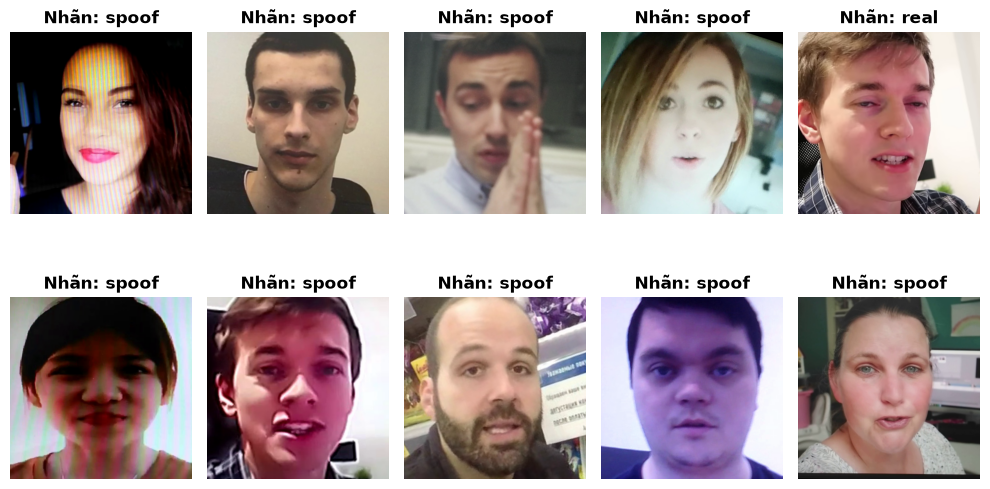

In [5]:
# Tạo một figure chứa lưới 2 hàng, 5 cột. figsize để chỉnh tỷ lệ khung hình
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))

# Lấy ngẫu nhiên 10 chỉ số (index) từ tổng số ảnh
random_indices = random.sample(range(len(train_dataset)), 10)

for i, idx in enumerate(random_indices):
    # Lấy ảnh và chỉ số nhãn tương ứng
    img, label_idx = train_dataset[idx]
    label_name = class_names[label_idx]
    
    # Tính toán tọa độ hàng và cột trên lưới (grid)
    row = i // 5
    col = i % 5
    
    # Hiển thị ảnh
    axes[row, col].imshow(img)
    # Ghi chú tên nhãn ở trên cùng mỗi ảnh
    axes[row, col].set_title(f"Nhãn: {label_name}", fontsize=12, fontweight='bold')
    # Ẩn trục tọa độ x, y để hình nhìn gọn gàng hơn
    axes[row, col].axis('off')

# Tự động căn chỉnh khoảng cách giữa các khung hình để không bị đè chữ
plt.tight_layout()
plt.show()

## Kiểm tra nhãn

Tỉ lệ lệch nhãn (Class Imbalance) trong tập Train: {'real': '14.74%', 'spoof': '85.26%'}


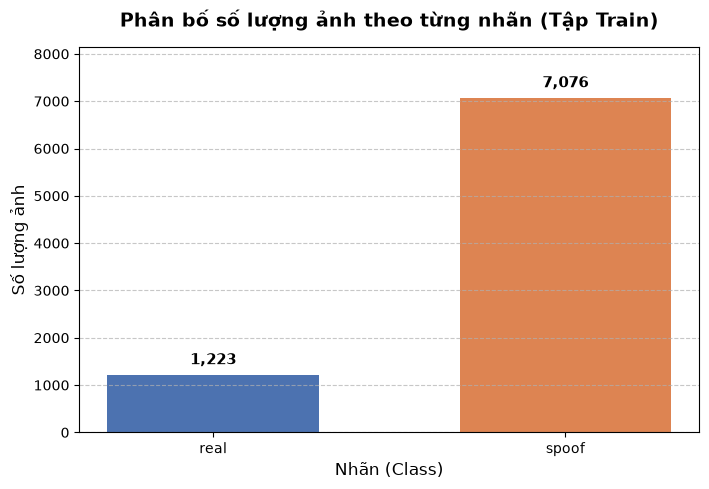

In [8]:
# Tách tên nhãn và số lượng tương ứng thành 2 danh sách
labels = list(class_counts.keys())
counts = list(class_counts.values())

print("Tỉ lệ lệch nhãn (Class Imbalance) trong tập Train:", {label: f"{count / len(train_dataset) * 100:.2f}%" for label, count in class_counts.items()})

# Thiết lập kích thước khung hình
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ cột với màu sắc phân biệt (ví dụ: xanh và cam)
bars = plt.bar(labels, counts, color=['#4C72B0', '#DD8452'], width=0.6)

# Tiêu đề và nhãn trục
plt.title('Phân bố số lượng ảnh theo từng nhãn (Tập Train)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhãn (Class)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)

# Ghi chú số liệu cụ thể lên đỉnh mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.02), 
             f"{int(yval):,}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tăng không gian trục Y thêm 15% để số liệu trên cột không bị lẹm vào viền trên
plt.ylim(0, max(counts) * 1.15) 

# Thêm lưới ngang để dễ gióng số liệu
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.show()

Tập dữ liệu huấn luyện đang bị mất cân bằng nhãn trầm trọng khi số lượng ảnh giả mạo (spoof) áp đảo gấp gần 6 lần ảnh thật (real), đòi hỏi quy trình huấn luyện phải tích hợp các kỹ thuật cân bằng dữ liệu như `WeightedRandomSampler` hoặc sử dụng hàm mất mát `Focal Loss` để ngăn chặn mô hình học thiên lệch.

## Điều chỉnh tham số chỉnh ảnh

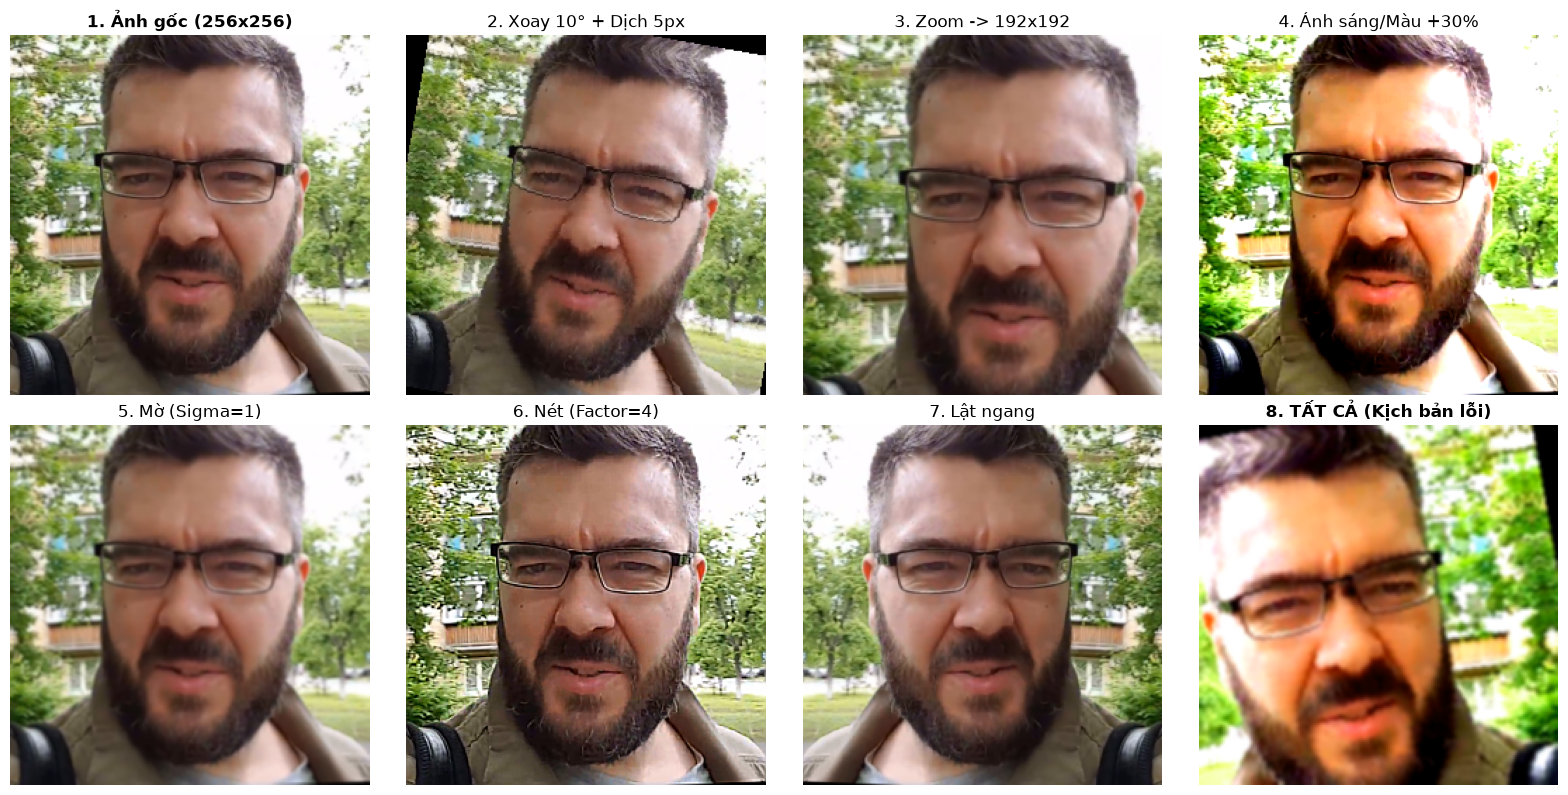

In [121]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms.functional as TF

def visualize_report_aug(img):
    """Mã dùng để vẽ hình báo cáo: Cố tình giữ phép xoay để thấy lỗi"""
    img_base = TF.resize(img, (256, 256))
    
    # 2. Xoay 10 độ & Dịch 5px (Tạo viền đen/phản chiếu lỗi để làm báo cáo)
    img_pad = TF.pad(img_base, padding=10, padding_mode='reflect')
    img_affine = TF.affine(img_pad, angle=10, translate=(5, 5), scale=1.0, shear=0)
    img_affine = TF.center_crop(img_affine, 256)
    
    # 3. Zoom & Cắt (Cắt khung 224x224, ép về 192x192)
    img_crop = TF.resized_crop(img_base, top=0, left=0, height=224, width=224, size=(192, 192))
    
    # 4. Ánh sáng & Màu sắc (Tăng 30%)
    img_color = TF.adjust_brightness(img_base, 1.30)
    img_color = TF.adjust_contrast(img_color, 1.30)
    img_color = TF.adjust_saturation(img_color, 1.30)
    img_color = TF.adjust_hue(img_color, 0.02)
    
    # 5. Làm mờ nhẹ
    img_blur = TF.gaussian_blur(img_base, kernel_size=[3, 3], sigma=[1.0])
    
    # 6. Tăng sắc nét (Hệ số 4)
    img_sharp = TF.adjust_sharpness(img_base, sharpness_factor=4.0)
    
    # 7. Lật ngang
    img_flip = TF.hflip(img_base)
    
    # 8. TẤT CẢ KẾT HỢP (Kịch bản xấu nhất có chứa lỗi xoay)
    img_all = TF.affine(TF.pad(img_base, padding=10, padding_mode='reflect'), angle=10, translate=(5, 5), scale=1.0, shear=0)
    img_all = TF.center_crop(img_all, 256)
    img_all = TF.resized_crop(img_all, top=0, left=0, height=224, width=224, size=(192, 192))
    img_all = TF.adjust_brightness(img_all, 1.30)
    img_all = TF.adjust_contrast(img_all, 1.30)
    img_all = TF.adjust_saturation(img_all, 1.30)
    img_all = TF.adjust_hue(img_all, 0.02)
    img_all = TF.gaussian_blur(img_all, kernel_size=[3, 3], sigma=[1.0])
    img_all = TF.hflip(img_all)
    
    # Trực quan hóa lên lưới 2x4
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
    
    axes[0, 0].imshow(img_base); axes[0, 0].set_title("1. Ảnh gốc (256x256)", fontweight='bold')
    axes[0, 1].imshow(img_affine); axes[0, 1].set_title("2. Xoay 10° + Dịch 5px")
    axes[0, 2].imshow(img_crop); axes[0, 2].set_title("3. Zoom -> 192x192")
    axes[0, 3].imshow(img_color); axes[0, 3].set_title("4. Ánh sáng/Màu +30%")
    
    axes[1, 0].imshow(img_blur); axes[1, 0].set_title("5. Mờ (Sigma=1)")
    axes[1, 1].imshow(img_sharp); axes[1, 1].set_title("6. Nét (Factor=4)")
    axes[1, 2].imshow(img_flip); axes[1, 2].set_title("7. Lật ngang")
    axes[1, 3].imshow(img_all); axes[1, 3].set_title("8. TẤT CẢ (Kịch bản lỗi)", fontweight='bold')
    
    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Đọc ngẫu nhiên 1 ảnh Real để test
real_dir = "../datasets/LCC_FASD/train/real"
real_images = [f for f in os.listdir(real_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
sample_img_name = random.choice(real_images)
img_path = os.path.join(real_dir, sample_img_name)
original_img = Image.open(img_path).convert('RGB')

visualize_report_aug(original_img)

**Kết luận**:

Trong quá trình tối ưu hóa pipeline dữ liệu cho bài toán Face Anti-Spoofing, chúng tôi đã tiến hành thử nghiệm và trực quan hóa hàng loạt các kỹ thuật Data Augmentation ở nhiều cường độ khác nhau. Dựa trên các đánh giá thực nghiệm, chúng tôi quyết định chọn và giữ lại các phép biến đổi bao gồm `RandomResizedCrop` (thu phóng ngẫu nhiên), `ColorJitter` (biến đổi ánh sáng/màu sắc), `GaussianBlur` (làm mờ) và `RandomAdjustSharpness` (tăng độ nét) ở biên độ an toàn. Ngược lại, chúng tôi quyết định loại bỏ hoàn toàn các phép biến đổi hình học như xoay ảnh (Rotation) và xê dịch (Translation/Affine). Nguyên nhân cốt lõi là do các phép toán này sinh ra các vệt viền đen (padding artifacts) ở góc ảnh và độ nhiễu của ảnh – một lỗ hổng nguy hiểm khiến mạng CNN dễ bị học vẹt (shortcut learning) thay vì tập trung trích xuất đặc trưng da mặt. Đồng thời, đối với các mẫu dữ liệu được chụp quá cận, việc xoay và dịch chuyển làm cắt lẹm các bộ phận quan trọng như cằm và mắt, phá hủy cấu trúc sinh trắc học tổng thể. Các kỹ thuật được chọn lọc cuối cùng vừa đảm bảo triệt tiêu hoàn toàn lỗi viền đen, vừa mô phỏng thành công các điều kiện môi trường thực tế như khoảng cách cầm thiết bị, điều kiện chiếu sáng và chất lượng cảm biến camera. Toàn bộ kịch bản biến đổi dữ liệu này, kết hợp cùng cơ chế lấy mẫu có trọng số để cân bằng nhãn, đã được chúng tôi thống nhất và triển khai hoàn chỉnh bên trong tệp `utils/data.py`.